# Data Exercise 1 – Wind Resource Assessment (Part 1)

---

## Background

You have been hired by **Aeolien Industries**, a wind power company, to perform a **wind resource assessment** for Mt. Tom. A wind resource assessment characterizes the features of the wind at a given location to determine how much power could be generated there.

You have been provided with a dataset collected at the site. Your goal is to analyze this data and write a report that describes the site and its wind resource. This notebook will walk you through the analysis step by step.

---

## How to use this notebook

A Jupyter notebook is made up of two types of cells:

- **Markdown cells** (like this one) contain explanatory text, instructions, and questions.
- **Code cells** contain Python code that you can run.

To **run a code cell**, click on it and press `Shift + Enter` (or click the ▶ button in the toolbar). The output will appear directly below the cell.

Work through the cells in order from top to bottom. Some cells are complete and just need to be run. Others have blanks (`___`) for you to fill in. Read the instructions in each markdown cell carefully before running the code below it.

---

## Step 0 – Import libraries and load the data

Before we can do any analysis, we need to tell Python which tools to use. In Python, extra tools come in **libraries** (also called packages or modules). We load them using the `import` statement.

The three libraries we'll use throughout this exercise are:

| Library | What it does |
|---|---|
| `pandas` | Reads spreadsheets/CSVs and organizes data into tables called DataFrames |
| `matplotlib` | Creates plots and figures |
| `numpy` | Provides math functions (mean, std, log, etc.) |

We also tell matplotlib to display plots **inline** (directly in the notebook) using the magic command `%matplotlib inline`.

Run the cell below to import the libraries. If you don't see any error messages, you're good to go!

In [2]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# This tells Jupyter to display plots inline (inside the notebook)
%matplotlib inline

print("Libraries loaded successfully!")

Libraries loaded successfully!


### Loading the data

Our data is stored in an Excel file: `HW1_MtToms_data.xlsx`. We'll load it into a **DataFrame** — think of a DataFrame as a spreadsheet table in Python.

The function `pd.read_excel()` reads an Excel file. We give it the filename as a **string** (in quotes). We save the result into a variable called `df` (short for DataFrame — a common convention).

After loading, we call `df.head()` to preview the first 5 rows of the table.

In [3]:
# Load the Excel data file

# URL to the excel file we'll be opening
url = "https://github.com/radryan1979/clim341/raw/refs/heads/main/Data/HW1_MtToms_data.xlsx"

df = pd.read_excel(url)

# Preview the first 5 rows
df.head()

,sample,Hour,m/s
0,1,0.166667,1.609340
1,2,0.333333,1.162300
2,3,0.500000,1.162300
3,4,0.666667,0.849376
4,5,0.833333,1.162300


You should see a table with three columns:
- **`sample`** – a sequential sample number
- **`Hour`** – the time of each measurement, in decimal hours from the start of the month
- **`m/s`** – wind speed in meters per second

---

## Question 1 – Describe the site

Mt. Tom is located in the northeastern United States (Massachusetts). Before analyzing the data, it's useful to understand the physical setting — the landscape, climate, and geography — because these all influence the wind resource.

Do a quick web search or use course materials to answer the following. Write your answer in the **text box below** (double-click the cell to edit it).

**✏️ Your answer (1–2 sentences):**

*What can you say about the area around Mt. Tom? Consider the terrain, vegetation, and regional climate.*

Write your answer here.

---

## Question 2 – Describe the dataset

Before diving into statistics, it's good practice to understand the structure of your data. How many measurements are there? Over what time period? How frequently were they collected?

The code below uses several helpful DataFrame properties and methods:

- `df.shape` → returns `(rows, columns)` — the dimensions of the table
- `df.columns` → lists the column names
- `df.dtypes` → shows the data type of each column
- `df.describe()` → computes basic statistics for each numeric column

In [3]:
# How many rows and columns?
n_rows, n_cols = df.shape
print(f"The dataset has {n_rows} rows and {n_cols} columns.")

# Column names and data types
print("\nColumn names and types:")
print(df.dtypes)

The dataset has 4464 rows and 3 columns.

Column names and types:
sample      int64
Hour      float64
m/s       float64
dtype: object


Now let's figure out the **time frequency** of the data. Each `Hour` value increases by a fixed interval. We can find that interval by looking at the **difference** between consecutive Hour values.

Pandas has a built-in method called `.diff()` that computes the difference between each row and the one before it.

In [4]:
# Calculate the time step between measurements
# .diff() computes the difference between consecutive rows
# .iloc[1] grabs the second row (index 1) — the first meaningful difference
time_step_hours = df['Hour'].diff().iloc[1]
time_step_minutes = time_step_hours * 60

print(f"Time step between measurements: {time_step_hours:.4f} hours")
print(f"That is approximately {time_step_minutes:.1f} minutes")

Time step between measurements: 0.1667 hours
That is approximately 10.0 minutes


**✏️ Your answer:**

> *Describe the dataset in 2–3 sentences. What type of data is provided? What is the time frequency of the measurements in minutes? How many total data points are there?*

---

## Question 3 – Average monthly wind speed

To access a single column in a DataFrame, use square brackets with the column name as a string:

```python
df['column_name']
```

To compute the **mean** (average) of a column, chain `.mean()` onto the column:

```python
df['column_name'].mean()
```

The `f"...{variable:.2f}"` syntax is called an **f-string** — it lets us embed variables directly in text. The `:.2f` part formats the number to 2 decimal places.

In [6]:
# Calculate the average (mean) wind speed for the month
# The wind speed column is called 'm/s'
mean_wind_speed = df['m/s'].mean()

print(f"Average monthly wind speed: {mean_wind_speed:.2f} m/s")

Average monthly wind speed: 4.65 m/s


---

## Question 4 – Standard deviation of wind speed

The **standard deviation** tells us how spread out the wind speeds are around the mean. A large standard deviation means the wind is highly variable; a small one means it's fairly steady.

In pandas, `.std()` computes the standard deviation of a column — it works exactly like `.mean()`.

**Your turn:** In the cell below, compute the standard deviation of the `'m/s'` column and print it. Use the mean calculation above as a template.

In [ ]:
# TODO: Calculate the standard deviation of the wind speed
# Hint: replace .mean() with .std()
std_wind_speed = df['m/s'].___()  # <-- fill in the blank

print(f"Standard deviation of wind speed: {std_wind_speed:.2f} m/s")

Standard deviation of wind speed: 2.44 m/s


---

## Question 5 – Maximum and minimum wind speeds

Similar to `.mean()` and `.std()`, pandas provides `.max()` and `.min()` methods to find the highest and lowest values in a column.

**Your turn:** Fill in the two blanks below to compute the max and min wind speeds.

In [ ]:
# TODO: Calculate max and min wind speeds
max_wind_speed = df['m/s'].___()  # <-- fill in the blank
min_wind_speed = df['m/s'].___()  # <-- fill in the blank

# TODO: Fill in the variable name for each line below, replace ____
print(f"Highest recorded wind speed: {___:.2f} m/s")
print(f"Lowest recorded wind speed:  {___:.2f} m/s")

Highest recorded wind speed: 15.65 m/s
Lowest recorded wind speed:  0.00 m/s


---

## Question 6 – Plot wind speed vs. time

Now let's visualize the data. We'll use `matplotlib` to create a line plot of wind speed (y-axis) against time in decimal hours (x-axis).

Here's a quick guide to the plotting commands we'll use:

```python
fig, ax = plt.subplots(figsize=(12, 4))   # create a figure and axes; figsize=(width, height) in inches
ax.plot(x_data, y_data, ...)              # draw a line
ax.set_xlabel('Label for x-axis')        # label the x-axis
ax.set_ylabel('Label for y-axis')        # label the y-axis
ax.set_title('Title of the figure')      # add a title
ax.legend()                              # add a legend (needs a 'label=' in ax.plot)
plt.tight_layout()                       # prevents labels from being cut off
plt.show()                               # display the figure
```

We access the columns of our DataFrame as the x and y data:
- **x** → `df['Hour']` (time in decimal hours)
- **y** → `df['m/s']` (wind speed)

**Your turn:** The plot below is mostly complete — fill in the axis labels and title.

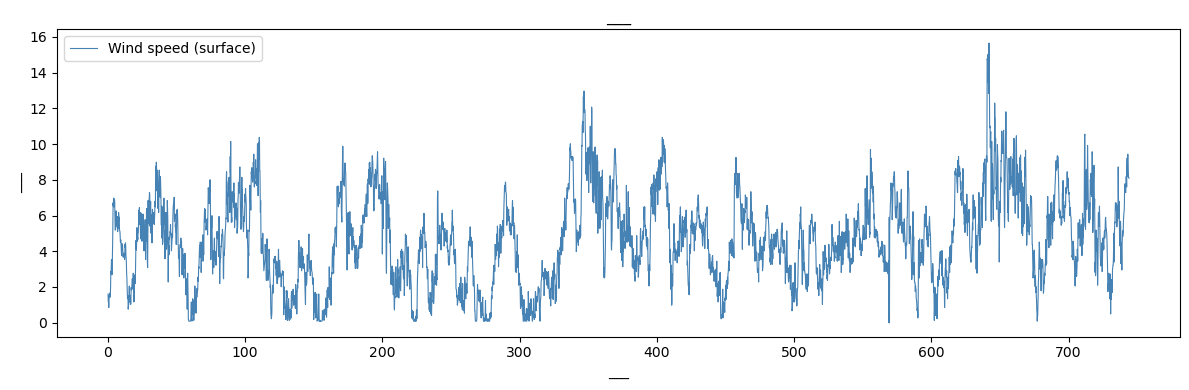

In [9]:
fig, ax = plt.subplots(figsize=(12, 4))

# Plot wind speed vs. time in hours
ax.plot(df['Hour'], df['m/s'], color='steelblue', linewidth=0.8, label='Wind speed (surface)')

# TODO: Add axis labels and a title
# Replace the ___ strings with meaningful labels
ax.set_xlabel('___')   # What is the x-axis showing? Include units.
ax.set_ylabel('___')   # What is the y-axis showing? Include units.
ax.set_title('___')    # Give the figure a descriptive title.

ax.legend()
plt.tight_layout()
plt.show()

**Additional Exploration** Change the numbers in the figsize=() and see how it changes the size of the plot.

---

## Question 7 – Convert hours to decimal days and replot

The `Hour` column gives time in decimal hours since the start of the month. This is a bit unwieldy, it's easier to interpret the x-axis in **decimal days**.

The conversion is simple:

$$\text{Day} = \frac{\text{Hour}}{24}$$

In pandas, we can create a **new column** in the DataFrame by assigning to it with a new name:

```python
df['new_column_name'] = df['existing_column'] / some_number
```

**Your turn:** In the cell below, create a new column called `'Day'` by dividing the `'Hour'` column by 24. Then replot the data using `'Day'` on the x-axis.

In [ ]:
# TODO: Create a new 'Day' column
# Hint: divide df['Hour'] by the number of hours in a day
df['Day'] = df['Hour'] / ___   # <-- fill in the blank

# Verify it worked by previewing the updated DataFrame
df.head()

In [ ]:
# Replot using decimal day on the x-axis
fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(df['Day'], df['m/s'], color='steelblue', linewidth=0.8, label='Wind speed (surface)')

# TODO: Add axis labels and a title (update from Question 6 — the x-axis unit has changed!)
ax.set_xlabel('___')
ax.set_ylabel('___')
ax.set_title('___')

ax.legend()
plt.tight_layout()
plt.show()

---

## Question 8 – Extrapolate wind speed to hub height using the log law

Most weather stations measure wind at about 2–3 m above the surface. But wind turbine hubs are typically anywhere from 40–80 m up. Since wind speed increases with height, we need to **extrapolate** the surface measurement upward.

We do this with the **logarithmic wind profile (log law)**:

$$U_{\text{hub}} = U_{\text{station}} \times \frac{\ln(z_{\text{hub}} / z_0)}{\ln(z_{\text{station}} / z_0)}$$

Where:
- $U_{\text{station}}$ = wind speed measured at the station (m/s)
- $z_{\text{station}}$ = height of the sensor = **2.5 m**
- $z_{\text{hub}}$ = turbine hub height = **60 m**
- $z_0$ = surface roughness length (depends on terrain; see table below)

The `np.log()` function computes the **natural logarithm** (ln). We'll apply it element-wise to the entire column at once — this is called **vectorized** computation and is one of Python/NumPy's biggest strengths.

### Choosing a roughness length $z_0$

| Surface type | $z_0$ (m) |
|---|---|
| Open water, smooth mud | 0.0002 |
| Open flat terrain, grass | 0.03 |
| Low crops, occasional obstacles | 0.10 |
| High crops, scattered buildings | 0.25 |
| Forests, suburbs | 0.5 |
| Dense urban, tall buildings | 1.0–2.0 |

Based on the site description you wrote in Question 1, choose an appropriate $z_0$ value and set it in the cell below.

In [ ]:
# --- Parameters for the log law ---
z_station = 2.5       # height of sensor (meters)
z_hub     = 60.0      # turbine hub height (meters)

# TODO: Choose z0 based on the surface type at Mt. Tom
# Replace the ___ with a value from the table above
z0 = ___              # surface roughness length (meters)

# --- Apply the log law ---
# np.log() computes the natural logarithm (ln)
# This operation applies to every row in the column at once
df['m/s_hub'] = df['m/s'] * (np.log(z_hub / z0) / np.log(z_station / z0))

print(f"Using z0 = {z0} m")
print(f"Log-law scaling factor: {np.log(z_hub/z0)/np.log(z_station/z0):.3f}")
print(f"\nFirst 5 rows of updated data:")
df[['Day', 'm/s', 'm/s_hub']].head()

In [ ]:
# Plot both surface wind speed AND hub-height wind speed on the same axes
fig, ax = plt.subplots(figsize=(12, 4))

# Surface wind speed (already plotted in Q7)
ax.plot(df['Day'], df['m/s'],     color='steelblue', linewidth=0.8, label='Surface (2.5 m)')

# Hub-height wind speed
ax.plot(df['Day'], df['m/s_hub'], color='tomato',    linewidth=0.8, label='Hub height (60 m)')

# TODO: Add labels and title
ax.set_xlabel('___')
ax.set_ylabel('___')
ax.set_title('___')

ax.legend()
plt.tight_layout()
plt.show()

**✏️ Your answer:**

> *What do you notice about the relationship between winds at hub height vs. winds at the surface? Is the hub-height wind always higher? By roughly how much?*

Write your answer here.

---

## Question 9 – Operational wind speed percentage

Wind turbines only operate within a specific range of wind speeds:
- **Cut-in speed**: 3 m/s — below this, there isn't enough wind to turn the turbine
- **Cut-out speed**: 15 m/s — above this, the turbine is shut down for safety

We want to know: **what fraction of the time is the wind within this operational range at hub height?**

### Boolean indexing in pandas

In Python, we can filter a DataFrame using **conditions** (True/False tests). For example:

```python
df['m/s_hub'] >= 3       # True for each row where hub wind speed is >= 3 m/s
df['m/s_hub'] <= 15      # True for each row where hub wind speed is <= 15 m/s
```

We can combine conditions with `&` (and) to require **both** to be true:

```python
(df['m/s_hub'] >= 3) & (df['m/s_hub'] <= 15)   # True only if BOTH conditions hold
```

Calling `.sum()` on a boolean series counts the number of `True` values.

In [ ]:
# Define the cut-in and cut-out wind speeds
cut_in  = 3.0   # m/s
cut_out = 15.0  # m/s

# Total number of data points
total_points = len(df)

# Create a boolean (True/False) mask for operational wind speeds
# The parentheses around each condition are required when combining with &
operational_mask = (df['m/s_hub'] >= cut_in) & (df['m/s_hub'] <= cut_out)

# Count how many data points fall within the operational range
# .sum() on a boolean series counts the number of True values
n_operational = operational_mask.sum()

# Calculate the percentage
pct_operational = (n_operational / total_points) * 100

print(f"Total data points:              {total_points}")
print(f"Points in operational range:    {n_operational}")
print(f"Percentage operational:         {pct_operational:.1f}%")

Let's also count how many points fall **below cut-in** and **above cut-out** separately, so we understand which limit is more constraining for this site.

In [ ]:
# Below cut-in (too calm)
n_below_cutin  = (df['m/s_hub'] < cut_in).sum()

# Above cut-out (too stormy)
n_above_cutout = (df['m/s_hub'] > cut_out).sum()

print(f"Below cut-in  (< {cut_in} m/s):  {n_below_cutin} points  ({100*n_below_cutin/total_points:.1f}%)")
print(f"Above cut-out (> {cut_out} m/s): {n_above_cutout} points  ({100*n_above_cutout/total_points:.1f}%)")
print(f"Operational range:              {n_operational} points  ({pct_operational:.1f}%)")

**✏️ Your answer:**

> *What percentage of the time is the turbine operational? Is this site a good candidate for wind power? What is the primary limiting factor — too little wind, or too much?*

Write your answer here.

---

## Summary table

Run the cell below to print a clean summary of all the statistics you've calculated. This is useful for your report!

In [ ]:
print("=" * 45)
print("  Mt. Tom Wind Resource Summary")
print("=" * 45)
print(f"  Mean wind speed (surface):    {df['m/s'].mean():.2f} m/s")
print(f"  Std dev (surface):            {df['m/s'].std():.2f} m/s")
print(f"  Max wind speed (surface):     {df['m/s'].max():.2f} m/s")
print(f"  Min wind speed (surface):     {df['m/s'].min():.2f} m/s")
print("-" * 45)
print(f"  Mean wind speed (hub, 60 m):  {df['m/s_hub'].mean():.2f} m/s")
print(f"  Std dev (hub):                {df['m/s_hub'].std():.2f} m/s")
print(f"  Max wind speed (hub):         {df['m/s_hub'].max():.2f} m/s")
print(f"  Min wind speed (hub):         {df['m/s_hub'].min():.2f} m/s")
print("-" * 45)
print(f"  Operational fraction:         {pct_operational:.1f}%")
print("=" * 45)

---

## 🎉 You're done with Part 1!

**Make sure you submit this Colab notebook link to Canvas and be sure the share settings are set to "Anyone with the link"**

You've used Python to:
- Load and inspect a real meteorological dataset
- Compute summary statistics (mean, standard deviation, max, min)
- Create and label publication-quality figures
- Apply a physical formula (the log law) to extrapolate wind speed with height
- Use boolean indexing to identify and count data meeting specific criteria
